# K-Means Clustering

## Objective:
- Segment customers into different groups based on behavior
- Identify patterns in income and spending

## Why Clustering?
- Unsupervised learning technique
- Helps in customer segmentation
- Useful for business decision-making

## Algorithm Used:
- K-Means Clustering

## Steps:
1. Determine optimal number of clusters (Elbow Method)
2. Apply K-Means algorithm
3. Visualize clusters
4. Interpret results

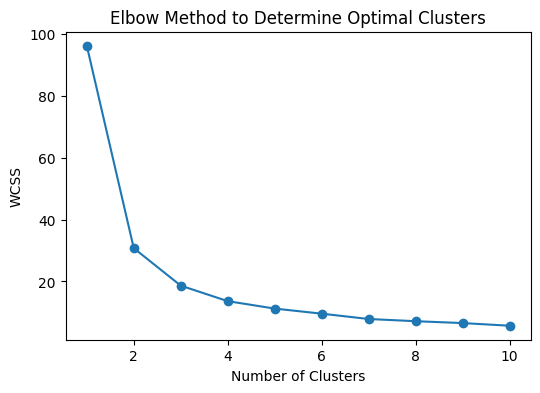

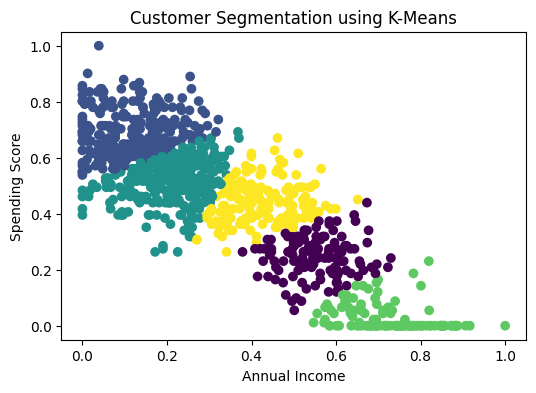


Cluster Counts:
Cluster
2    311
1    264
4    161
0    128
3    118
Name: count, dtype: int64

Cluster-wise Mean Values:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                  0.551480                0.246823
1                  0.119235                0.689602
2                  0.210938                0.518356
3                  0.726280                0.030359
4                  0.426017                0.437991

K-Means Clustering Completed Successfully ✅


In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load processed dataset
df = pd.read_csv('../data/processed/clean_data.csv')

# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# -------------------------------
# STEP 1: ELBOW METHOD
# -------------------------------
wcss = []  # Within-cluster sum of squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method to Determine Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

# Save plot
plt.savefig('../outputs/plots/elbow_method.png')

plt.show()

# -------------------------------
# STEP 2: APPLY K-MEANS
# -------------------------------
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# -------------------------------
# STEP 3: VISUALIZE CLUSTERS
# -------------------------------
plt.figure(figsize=(6,4))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

# Save plot
plt.savefig('../outputs/plots/kmeans_clusters.png')

plt.show()

# -------------------------------
# STEP 4: CLUSTER ANALYSIS
# -------------------------------
print("\nCluster Counts:")
print(df['Cluster'].value_counts())

print("\nCluster-wise Mean Values:")
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

# -------------------------------
# STEP 5: SAVE RESULT
# -------------------------------
df.to_csv('../data/processed/clustered_data.csv', index=False)

print("\nK-Means Clustering Completed Successfully ✅")